In [1]:
import pandas as pd
import numpy as np

# Load
df = pd.read_csv('Nifty50Data - Sheet1.csv')

# Rename — count matches exactly (15 columns confirmed)
df.columns = ['Symbol','Open','High','Low','Prev_Close','LTP',
              'Indicative_Close','Change','Pct_Change',
              'Volume','Value_Cr','High_52W','Low_52W',
              'Chng_30D','Chng_365D']

# Clean numeric columns — strip commas, convert to numbers
for col in df.columns[1:]:
    df[col] = pd.to_numeric(
                  df[col].astype(str).str.replace(',', '', regex=False),
                  errors='coerce'
              )

# Drop the NIFTY 50 index row
df = df[df['Symbol'] != 'NIFTY 50'].reset_index(drop=True)

# Verify
print("Shape:", df.shape)          # should be (50, 15)
print(df[['Symbol','LTP','Chng_30D','Chng_365D']].head(5))

Shape: (50, 15)
       Symbol     LTP  Chng_30D  Chng_365D
0    HDFCBANK   782.7     -4.22     -18.93
1  ADANIPORTS  1756.0     20.83      31.72
2    RELIANCE  1420.0      5.63       1.19
3         TCS  2378.1     -7.09     -31.06
4  APOLLOHOSP  8035.0      8.64      17.36


In [5]:
# Step 2 — Compute metrics from single-day snapshot

# 1. Drawdown from 52W high (how much has it fallen from peak)
df['Drawdown_Pct'] = ((df['LTP'] - df['High_52W']) / df['High_52W']) * 100

# 2. Recovery from 52W low (how much has it bounced from trough)
df['Recovery_Pct'] = ((df['LTP'] - df['Low_52W']) / df['Low_52W']) * 100

# 3. Position in 52W range (0 = at yearly low, 1 = at yearly high)
df['Range_Position'] = (df['LTP'] - df['Low_52W']) / (df['High_52W'] - df['Low_52W'])

# 4. Portfolio weight by market value
df['Weight'] = df['Value_Cr'] / df['Value_Cr'].sum()

# 5. Simple risk score (0-1) based on drawdown and volatility proxy
df['Risk_Score'] = (1 - df['Range_Position']) * 0.5 + \
                   (df['Chng_365D'].abs() / df['Chng_365D'].abs().max()) * 0.5

# Preview
print(df[['Symbol','LTP','Drawdown_Pct','Recovery_Pct',
          'Range_Position','Weight','Risk_Score']].round(3))

        Symbol       LTP  Drawdown_Pct  Recovery_Pct  Range_Position  Weight  \
0     HDFCBANK    782.70       -23.302         7.713           0.191   0.099   
1   ADANIPORTS   1756.00        -2.009        36.071           0.928   0.057   
2     RELIANCE   1420.00       -11.900        10.078           0.404   0.043   
3          TCS   2378.10       -34.497         1.360           0.025   0.041   
4   APOLLOHOSP   8035.00        -0.796        20.329           0.955   0.038   
5    COALINDIA    456.65        -7.043        23.871           0.718   0.037   
6         SBIN   1090.10       -11.711        44.289           0.698   0.036   
7    ICICIBANK   1265.00       -15.667         6.517           0.248   0.035   
8         INFY   1170.40       -32.269         1.792           0.036   0.033   
9   BHARTIARTL   1827.60       -15.953         4.620           0.189   0.031   
10         M&M   3351.60       -12.716        15.732           0.483   0.028   
11          LT   3985.90       -10.227  

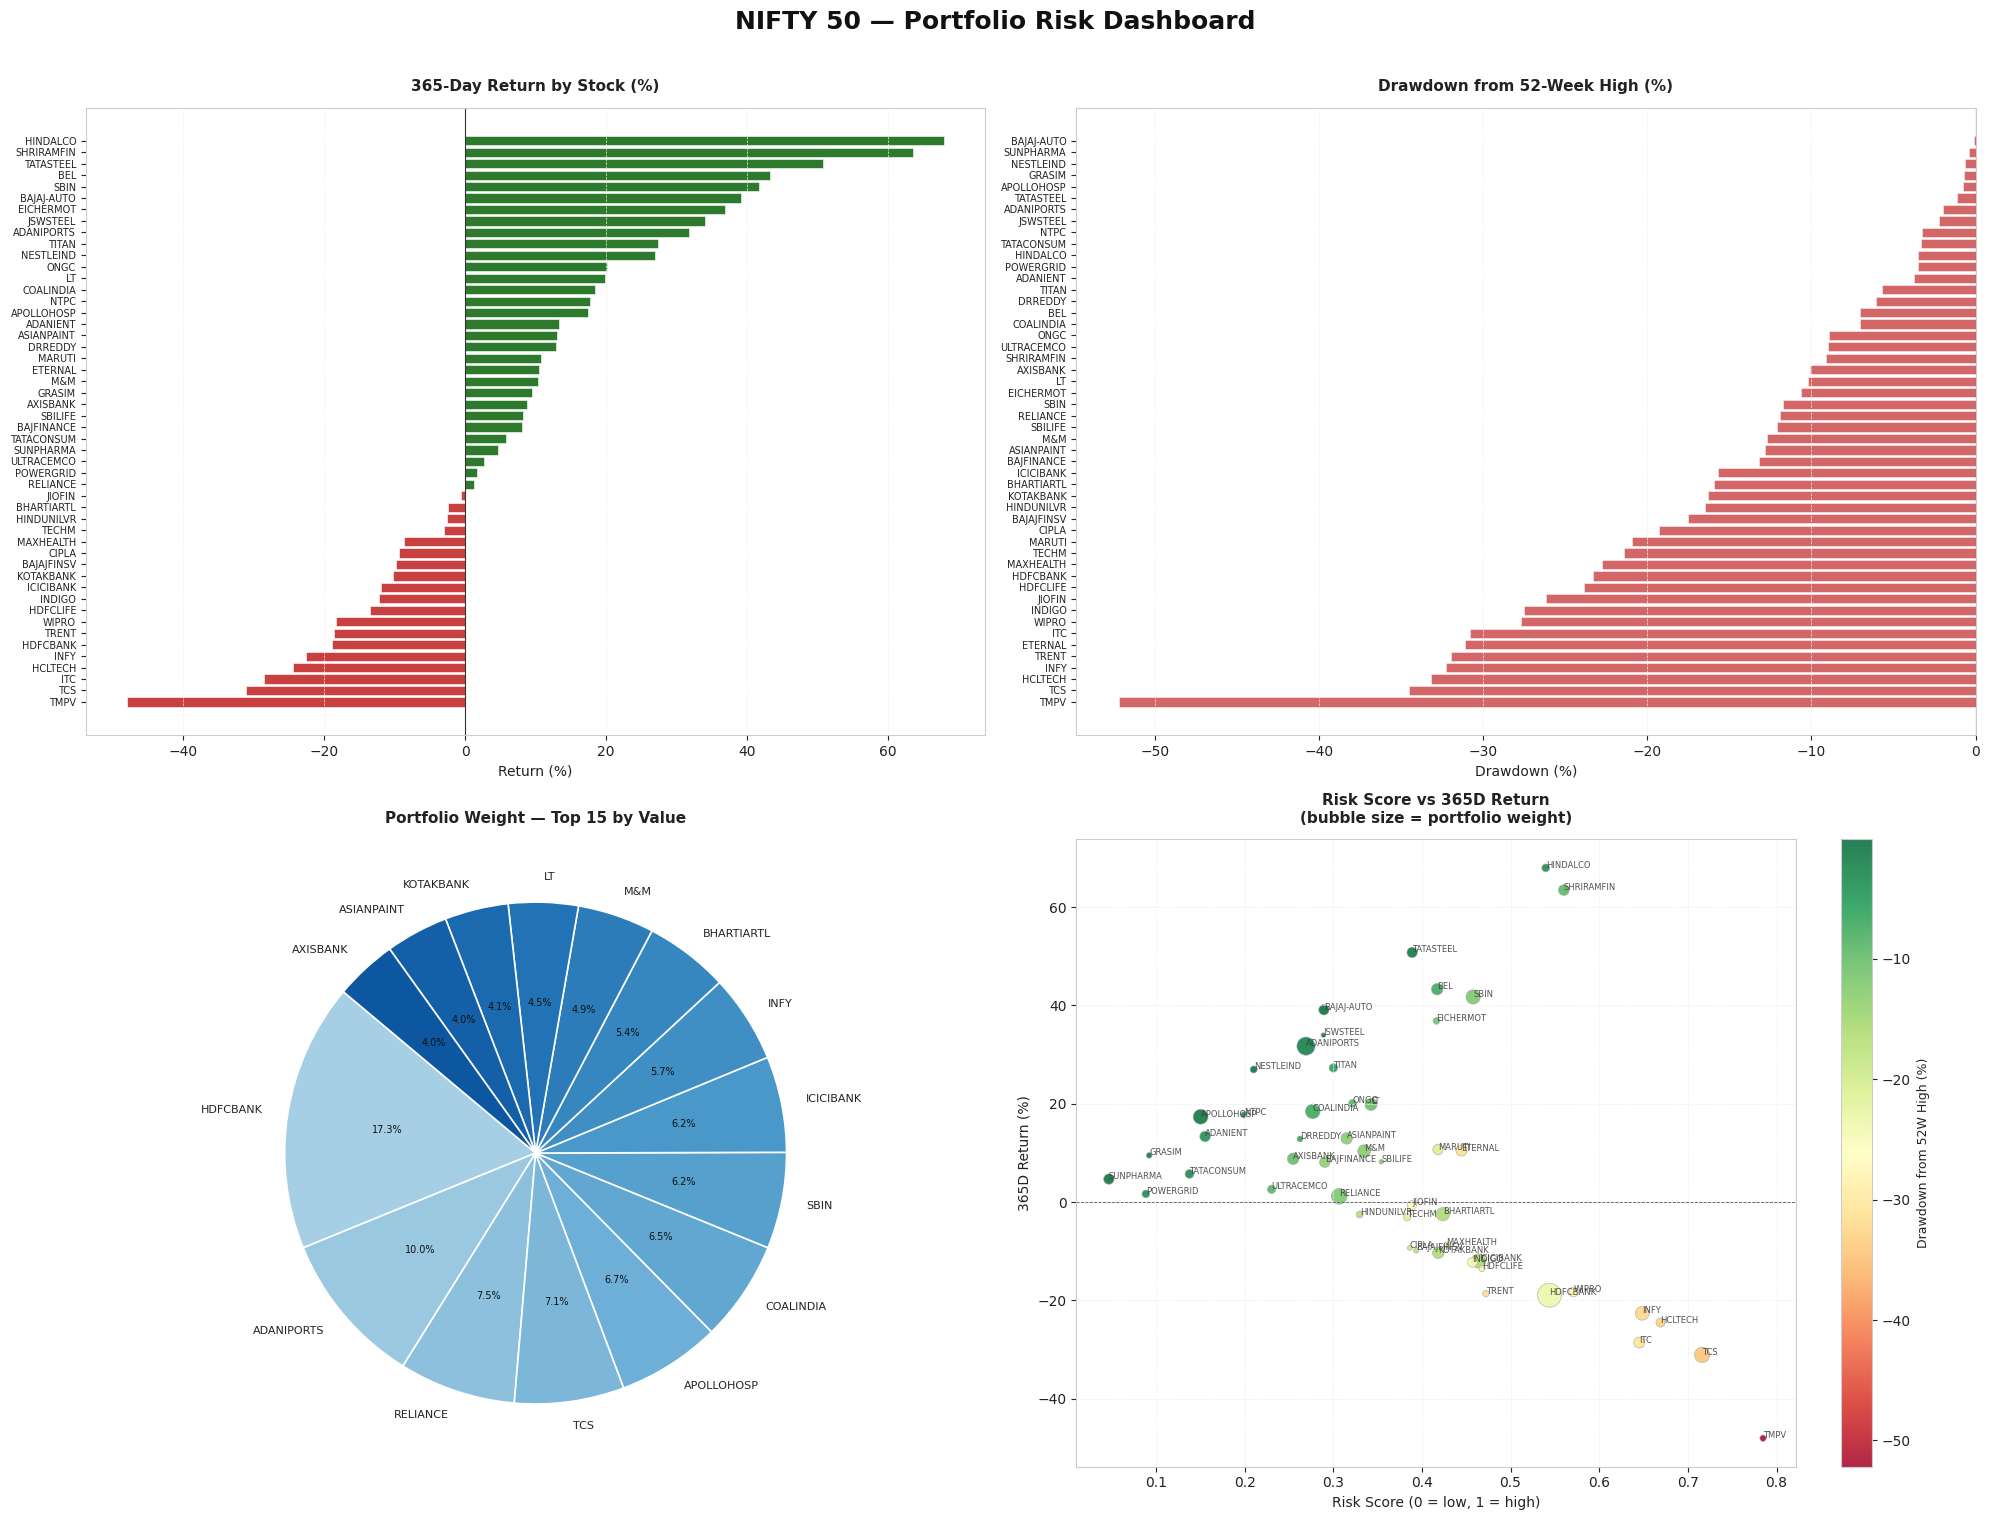

Saved!


In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Force light theme regardless of system settings
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#cccccc',
    'axes.labelcolor':   '#222222',
    'xtick.color':       '#222222',
    'ytick.color':       '#222222',
    'text.color':        '#222222',
    'grid.color':        '#eeeeee',
    'grid.linestyle':    '--',
    'grid.linewidth':    0.5,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    11,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
})

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.patch.set_facecolor('white')
fig.suptitle('NIFTY 50 — Portfolio Risk Dashboard',
             fontsize=18, fontweight='bold', color='#111111', y=1.01)

# ── Chart 1: 365D Return ─────────────────────────────────────────────────────
ax1 = axes[0, 0]
sorted_365 = df.sort_values('Chng_365D')
colors = ['#c94040' if x < 0 else '#2d7a2d' for x in sorted_365['Chng_365D']]
bars = ax1.barh(sorted_365['Symbol'], sorted_365['Chng_365D'],
                color=colors, edgecolor='white', linewidth=0.4)
ax1.axvline(0, color='#333333', linewidth=0.8)
ax1.set_title('365-Day Return by Stock (%)')
ax1.set_xlabel('Return (%)')
ax1.tick_params(axis='y', labelsize=7)
ax1.set_facecolor('white')
ax1.grid(axis='x')

# ── Chart 2: Drawdown from 52W High ──────────────────────────────────────────
ax2 = axes[0, 1]
sorted_dd = df.sort_values('Drawdown_Pct')
ax2.barh(sorted_dd['Symbol'], sorted_dd['Drawdown_Pct'],
         color='#c94040', alpha=0.8, edgecolor='white', linewidth=0.4)
ax2.axvline(0, color='#333333', linewidth=0.8)
ax2.set_title('Drawdown from 52-Week High (%)')
ax2.set_xlabel('Drawdown (%)')
ax2.tick_params(axis='y', labelsize=7)
ax2.set_facecolor('white')
ax2.grid(axis='x')

# ── Chart 3: Portfolio Weight top 15 ─────────────────────────────────────────
ax3 = axes[1, 0]
top15 = df.nlargest(15, 'Weight')
wedge_colors = plt.cm.Blues(np.linspace(0.35, 0.85, 15))
wedges, texts, autotexts = ax3.pie(
    top15['Weight'], labels=top15['Symbol'],
    autopct='%1.1f%%', textprops={'fontsize': 8, 'color': '#222222'},
    colors=wedge_colors, startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
for at in autotexts:
    at.set_fontsize(7)
    at.set_color('#111111')
ax3.set_title('Portfolio Weight — Top 15 by Value')
ax3.set_facecolor('white')

# ── Chart 4: Risk Scatter ─────────────────────────────────────────────────────
ax4 = axes[1, 1]
scatter = ax4.scatter(
    df['Risk_Score'], df['Chng_365D'],
    c=df['Drawdown_Pct'], cmap='RdYlGn',
    s=df['Weight']*3000, alpha=0.85,
    edgecolors='#aaaaaa', linewidth=0.5
)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Drawdown from 52W High (%)', color='#222222', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#222222')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#222222')

for _, row in df.iterrows():
    ax4.annotate(row['Symbol'], (row['Risk_Score'], row['Chng_365D']),
                 fontsize=6, color='#333333', alpha=0.85)
ax4.axhline(0, color='#555555', linewidth=0.6, linestyle='--')
ax4.set_title('Risk Score vs 365D Return\n(bubble size = portfolio weight)')
ax4.set_xlabel('Risk Score (0 = low, 1 = high)')
ax4.set_ylabel('365D Return (%)')
ax4.set_facecolor('white')
ax4.grid(True)

plt.tight_layout()
plt.savefig('nifty50_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved!")

In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '365-Day Return (%)',
        'Drawdown from 52W High (%)',
        'Portfolio Weight — Top 15',
        'Risk Score vs 365D Return'
    ),
    specs=[
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "pie"}, {"type": "scatter"}]
    ]
)

# Chart 1 — 365D Return
sorted_365 = df.sort_values('Chng_365D')
colors_365 = ['#c94040' if x < 0 else '#2d7a2d' for x in sorted_365['Chng_365D']]
fig.add_trace(go.Bar(
    x=sorted_365['Chng_365D'], y=sorted_365['Symbol'],
    orientation='h', marker_color=colors_365,
    hovertemplate='%{y}: %{x:.1f}%<extra></extra>'
), row=1, col=1)

# Chart 2 — Drawdown
sorted_dd = df.sort_values('Drawdown_Pct')
fig.add_trace(go.Bar(
    x=sorted_dd['Drawdown_Pct'], y=sorted_dd['Symbol'],
    orientation='h', marker_color='#c94040',
    hovertemplate='%{y}: %{x:.1f}%<extra></extra>'
), row=1, col=2)

# Chart 3 — Pie
top15 = df.nlargest(15, 'Weight')
fig.add_trace(go.Pie(
    labels=top15['Symbol'], values=top15['Weight'],
    hole=0.4, textinfo='percent+label',
    hovertemplate='%{label}: %{percent}<extra></extra>'
), row=2, col=1)

# Chart 4 — Scatter
fig.add_trace(go.Scatter(
    x=df['Risk_Score'], y=df['Chng_365D'],
    mode='markers+text',
    text=df['Symbol'], textposition='top center',
    textfont=dict(size=7),
    marker=dict(
        size=df['Weight']*800,
        color=df['Drawdown_Pct'],
        colorscale='RdYlGn',
        showscale=True,
        colorbar=dict(title='Drawdown %', x=1.05)
    ),
    hovertemplate='%{text}<br>Risk: %{x:.2f}<br>Return: %{y:.1f}%<extra></extra>'
), row=2, col=2)

fig.update_layout(
    height=900,
    title_text='NIFTY 50 — Portfolio Risk Dashboard',
    title_font=dict(size=18),
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(color='#222222')
)
fig.update_xaxes(showgrid=True, gridcolor='#eeeeee')
fig.update_yaxes(showgrid=True, gridcolor='#eeeeee')

# Save as HTML instead of showing inline
fig.write_html('nifty50_dashboard.html')
print("Saved! Download nifty50_dashboard.html and open in your browser.")

Saved! Download nifty50_dashboard.html and open in your browser.
